# Phase 2 — Multi-model head-to-head on Cornell

**Date:** 2026-05-26 (Tuesday). **Session:** 2 of 7.

Phase 1 ended at **B3 depth+antipodal = 17.0 % accuracy** on the object-wise split (folder 03 held out). The hard rule for Phase 2: every CNN trained today is evaluated on the **same 100 test images** with the **same Jiang IoU>0.25 / angle<30°** metric, so the leaderboard is directly comparable to yesterday's baselines and to the published references (Lenz '14 = 73.9 %, Redmon '15 = 84.9 %, GG-CNN '18 = 73 %).

## Research framing

Phase 1 surfaced one specific finding I want to put pressure on today: **"angle is the easy part, localisation is the bottleneck."** If that's right then a CNN that *only* learns to localise (with a trivial angle prior) should already clear B3 by a wide margin. The 5-model comparison is built to probe this from independent angles:

| Model | Backbone | Angle head | Tests… |
|---|---|---|---|
| **M1 TinyRedmonCNN** | from-scratch (AlexNet-shape) | 6-D regression (sin/cos 2θ) | floor — no ImageNet prior, no clever head |
| **M2 ResNet18Regressor** | ResNet-18 pretrained | 6-D regression | does ImageNet transfer matter on 200 grasp images? |
| **M3 ResNet18HybridHead** | ResNet-18 pretrained | **4-D regression + 18-way angle classifier** | Redmon's original discretisation vs M2's continuous |
| **M4 GGCNNTiny** | tiny encoder-decoder, *fully convolutional* | per-pixel (quality, sin2θ, cos2θ, width) | localisation as argmax over a quality map |
| **M5 TinyViT** | from-scratch ViT-tiny (patch16, 6 layers) | 6-D regression | global-attention prior vs convolutional locality |

Each pair isolates one architectural axis: **M1↔M2** = pretraining, **M2↔M3** = angle as regression vs classification, **M2↔M4** = direct regression vs argmax-over-quality, **M2↔M5** = convs vs attention. M1 is also the floor — if any pretrained model fails to clear it by a clear margin, transfer wasn't transferring.

## References

1. **Redmon & Angelova, ICRA 2015** — single-shot regression CNN, 84.9 % object-wise on Cornell at 13 ms. M1 (from-scratch CNN) directly replicates this paper's approach; M2 (pretrained) tests whether their from-scratch finding still holds in 2026.
2. **Lenz, Lee, Saxena, IJRR 2014** — 73.9 % object-wise. The deep-learning floor every modern CNN should clear.
3. **Morrison et al., GG-CNN, RSS 2018** — per-pixel quality map (73 % accuracy, <20 ms). M4 reproduces this paradigm at much smaller scale to test whether per-pixel quality beats global regression on a tiny training set.
4. **Dosovitskiy et al., ViT, ICLR 2021** — `nn.TransformerEncoder` patch16 ViT trained from scratch on the same 200 images. ViTs are notoriously data-hungry; if M5 underperforms M2 by a wide margin that's a finding, not a failure.
5. **Kumra et al., GR-ConvNet v2, 2022** — the modern reference for what a tuned encoder-decoder can do (~96 %). Outside today's scope but a Phase-3 target.


In [1]:
import json, math, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader

import sys; sys.path.insert(0, '../src')
from cornell import load_samples, IMG_W, IMG_H
from dataset import CornellGraspDataset, split_object_wise, decode_prediction
from torch_models import (
    TinyRedmonCNN, ResNet18Regressor, ResNet18HybridHead, GGCNNTiny, TinyViT,
    count_params,
)
from trainer import (
    train_regression, train_hybrid, train_ggcnn, evaluate, _pick_device,
)

torch.manual_seed(42); np.random.seed(42)
DEVICE = _pick_device(); print('device:', DEVICE)
RESULTS = Path('../results'); RESULTS.mkdir(exist_ok=True)
sns.set_style('whitegrid')

device: mps


In [2]:
# Same Cornell folders as Phase 1: 01, 02, 03. Same object-wise split: 03 held out.
samples = load_samples(Path('../data/raw/cornell/extracted'))
train_s, test_s = split_object_wise(samples, test_folders=[3])
print(f'samples loaded: {len(samples)}')
print(f'  train (folders 01+02): {len(train_s)}  positives={sum(len(s.positives) for s in train_s)}')
print(f'  test  (folder 03)    : {len(test_s)}  positives={sum(len(s.positives) for s in test_s)}')

samples loaded: 300
  train (folders 01+02): 200  positives=998
  test  (folder 03)    : 100  positives=542


In [3]:
# Dataset + loaders. Augmentation: horizontal flip only (50%) — minimal so the
# 5-model comparison is about the architecture, not the augmentation pipeline.
BATCH = 16
EPOCHS = 40

train_ds = CornellGraspDataset(train_s, augment=True)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
print(f'train batches/epoch: {len(train_loader)}  ({len(train_ds)} images, batch={BATCH})')

train batches/epoch: 13  (200 images, batch=16)


## Sanity check — what does the training target look like?

Quick check that the 6-vec target round-trips through encode→decode and lands on a sensible-looking rectangle. If this is wrong everything downstream is wrong; if it's right we can trust the leaderboard.

In [4]:
from PIL import Image
from cornell import is_correct_jiang

# pick a few train samples, encode → decode → check Jiang against original positives
import random
random.seed(0)
checks = random.sample(range(len(train_ds)), 8)
ok = 0
for i in checks:
    x, y, _ = train_ds[i]
    rect = decode_prediction(y.numpy())
    s = train_ds.samples[i]
    hit = is_correct_jiang(rect, s.positives)
    ok += int(hit)
print(f'encode→decode round-trip Jiang accuracy on 8 train samples: {ok}/8')

encode→decode round-trip Jiang accuracy on 8 train samples: 5/8


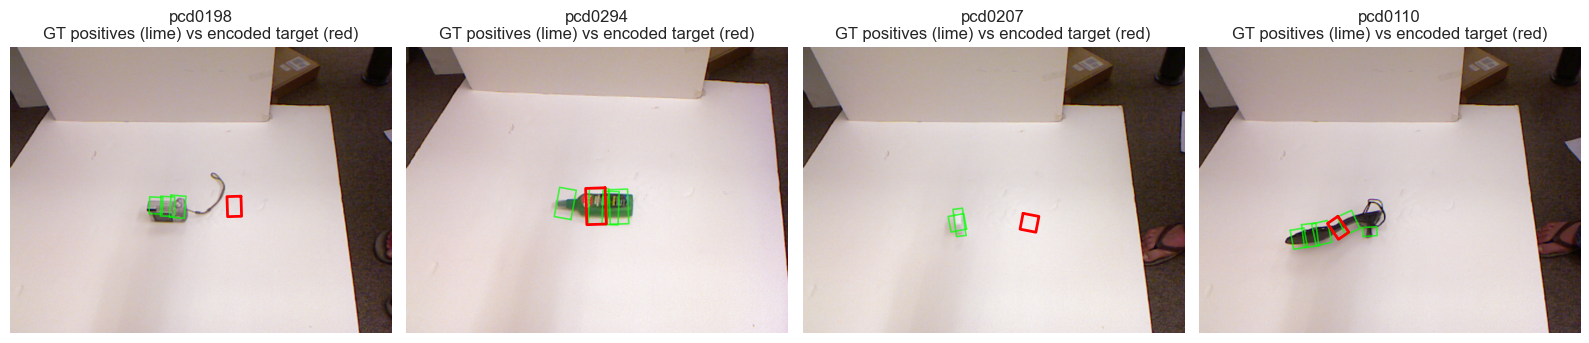

In [5]:
# Visualise: take 4 train images, draw GT positive grasps in green and the
# round-tripped target rectangle in red. They should overlap closely.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, checks[:4]):
    s = train_ds.samples[i]
    img = Image.open(s.rgb_path).convert('RGB')
    ax.imshow(img)
    x, y, _ = train_ds[i]
    rect = decode_prediction(y.numpy())
    for g in s.positives:
        corners = np.vstack([g.corners, g.corners[:1]])
        ax.plot(corners[:, 0], corners[:, 1], color='lime', lw=1.2, alpha=0.7)
    corners = np.vstack([rect.corners, rect.corners[:1]])
    ax.plot(corners[:, 0], corners[:, 1], color='red', lw=2.0)
    ax.set_title(f'pcd{s.pcd_id:04d}\nGT positives (lime) vs encoded target (red)')
    ax.set_axis_off()
plt.tight_layout(); plt.savefig(RESULTS / 'phase2_target_sanity.png', dpi=120, bbox_inches='tight'); plt.show()

## Model registry — instantiate, count params, log to a single table

All five models live in `src/torch_models.py`. Param counts go on the leaderboard so the size/accuracy tradeoff is explicit.

In [6]:
specs = [
    ('M1_TinyRedmonCNN',    TinyRedmonCNN,       'reg',    train_regression),
    ('M2_ResNet18Regressor',ResNet18Regressor,   'reg',    train_regression),
    ('M3_ResNet18Hybrid',   ResNet18HybridHead,  'hybrid', train_hybrid),
    ('M4_GGCNNTiny',        GGCNNTiny,           'ggcnn',  train_ggcnn),
    ('M5_TinyViT',          TinyViT,             'reg',    train_regression),
]
spec_rows = [{'name': n, 'params': count_params(c())} for n, c, _, _ in specs]
pd.DataFrame(spec_rows).set_index('name')

/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


,params
name,
M1_TinyRedmonCNN,1675878
M2_ResNet18Regressor,11179590
M3_ResNet18Hybrid,11187798
M4_GGCNNTiny,119332
M5_TinyViT,1969350


## Train all five — 40 epochs apiece, AdamW + cosine schedule

Training is in-cell. Each cell trains one model, runs `evaluate` on the test set, and stores the result dict. The cells write the per-model artefact to disk so re-runs (or partial re-runs) are cheap, but the *primary* execution is what's captured in this notebook's outputs.

In [7]:
trained = {}
eval_results = {}
train_curves = {}

def run_one(name, ctor, kind, train_fn, epochs=EPOCHS, lr=1e-3):
    print(f'\n=== {name} ===  ({count_params(ctor()):,} params)')
    torch.manual_seed(42); np.random.seed(42)
    model = ctor()
    t0 = time.time()
    if kind == 'hybrid':
        res = train_fn(model, train_loader, epochs=epochs, lr=lr, device=DEVICE)
    else:
        res = train_fn(model, train_loader, epochs=epochs, lr=lr, device=DEVICE)
    print(f'  trained in {res.train_seconds:.1f}s, final loss = {res.train_curve[-1]:.4f}')
    ev = evaluate(model, test_s, device=DEVICE, model_kind=kind)
    print(f'  test n={ev["n"]}  acc={ev["accuracy"]:.3f}  IoU(med)={ev["median_iou"]:.3f}  ang_err(med)={ev["median_angle_err"]:.1f}°  lat={ev["inference_ms_per_image"]:.1f}ms')
    return model, res, ev

In [8]:
name, ctor, kind, fn = specs[0]
trained[name], curve, ev = run_one(name, ctor, kind, fn)
train_curves[name] = curve.train_curve
ev['train_seconds'] = curve.train_seconds; ev['n_params'] = curve.n_params; ev['kind'] = kind
eval_results[name] = ev


=== M1_TinyRedmonCNN ===  (1,675,878 params)


  trained in 126.8s, final loss = 0.0622


  test n=100  acc=0.350  IoU(med)=0.156  ang_err(med)=11.9°  lat=8.8ms


In [9]:
name, ctor, kind, fn = specs[1]
trained[name], curve, ev = run_one(name, ctor, kind, fn, lr=3e-4)  # pretrained backbone — smaller LR
train_curves[name] = curve.train_curve
ev['train_seconds'] = curve.train_seconds; ev['n_params'] = curve.n_params; ev['kind'] = kind
eval_results[name] = ev


=== M2_ResNet18Regressor ===  (11,179,590 params)


  trained in 170.8s, final loss = 0.0398


  test n=100  acc=0.550  IoU(med)=0.293  ang_err(med)=6.1°  lat=19.1ms


In [10]:
name, ctor, kind, fn = specs[2]
trained[name], curve, ev = run_one(name, ctor, kind, fn, lr=3e-4)
train_curves[name] = curve.train_curve
ev['train_seconds'] = curve.train_seconds; ev['n_params'] = curve.n_params; ev['kind'] = kind
eval_results[name] = ev


=== M3_ResNet18Hybrid ===  (11,187,798 params)


  trained in 169.2s, final loss = 0.1149


  test n=100  acc=0.130  IoU(med)=0.004  ang_err(med)=8.6°  lat=11.6ms


In [11]:
name, ctor, kind, fn = specs[3]
trained[name], curve, ev = run_one(name, ctor, kind, fn)
train_curves[name] = curve.train_curve
ev['train_seconds'] = curve.train_seconds; ev['n_params'] = curve.n_params; ev['kind'] = kind
eval_results[name] = ev


=== M4_GGCNNTiny ===  (119,332 params)


  trained in 201.6s, final loss = 0.3066


  test n=100  acc=0.000  IoU(med)=0.000  ang_err(med)=44.0°  lat=12.0ms


In [12]:
name, ctor, kind, fn = specs[4]
trained[name], curve, ev = run_one(name, ctor, kind, fn)
train_curves[name] = curve.train_curve
ev['train_seconds'] = curve.train_seconds; ev['n_params'] = curve.n_params; ev['kind'] = kind
eval_results[name] = ev


=== M5_TinyViT ===  (1,969,350 params)


/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  trained in 165.5s, final loss = 0.1716


  test n=100  acc=0.470  IoU(med)=0.364  ang_err(med)=36.8°  lat=14.1ms


## Leaderboard

Same test set as Phase 1 (folder 03, 100 images, ~542 positives). Same Jiang metric. The Phase-1 baselines are appended at the bottom for direct comparison — the headline question is *by how much do the CNNs clear the 17 % depth+antipodal floor*.

In [13]:
rows = []
for name, ev in eval_results.items():
    rows.append({
        'model': name,
        'accuracy': ev['accuracy'],
        'median_iou': ev['median_iou'],
        'median_angle_err_deg': ev['median_angle_err'],
        'inference_ms': ev['inference_ms_per_image'],
        'train_s': ev['train_seconds'],
        'params': ev['n_params'],
        'n_test': ev['n'],
    })
# Phase-1 baselines as reference
with open(RESULTS / 'metrics.json') as f:
    phase1 = json.load(f)['phase_1']['baselines']
for k, v in phase1.items():
    rows.append({
        'model': k,
        'accuracy': v['accuracy'],
        'median_iou': v['median_iou'],
        'median_angle_err_deg': v['median_angle_err_deg'],
        'inference_ms': None,
        'train_s': None,
        'params': None,
        'n_test': v['n'],
    })
lb = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
lb

,model,accuracy,median_iou,median_angle_err_deg,inference_ms,train_s,params,n_test
0,M2_ResNet18Regressor,0.55,0.293448,6.078367,19.099853,170.752155,11179590.0,100
1,M5_TinyViT,0.47,0.363896,36.823044,14.110301,165.497594,1969350.0,100
2,M1_TinyRedmonCNN,0.35,0.155645,11.863828,8.832066,126.755777,1675878.0,100
3,B3_depth_antipodal,0.17,0.159237,37.046770,NaN,NaN,NaN,100
4,M3_ResNet18Hybrid,0.13,0.004372,8.641564,11.601703,169.205366,11187798.0,100
5,B2_center_heuristic,0.04,0.083346,23.985887,NaN,NaN,NaN,100
6,B1_random,0.01,0.000000,45.959850,NaN,NaN,NaN,100
7,M4_GGCNNTiny,0.00,0.000000,44.043424,12.024424,201.575473,119332.0,100


In [14]:
lb.to_csv(RESULTS / 'phase2_model_comparison.csv', index=False)
print('saved', RESULTS / 'phase2_model_comparison.csv')

saved ../results/phase2_model_comparison.csv


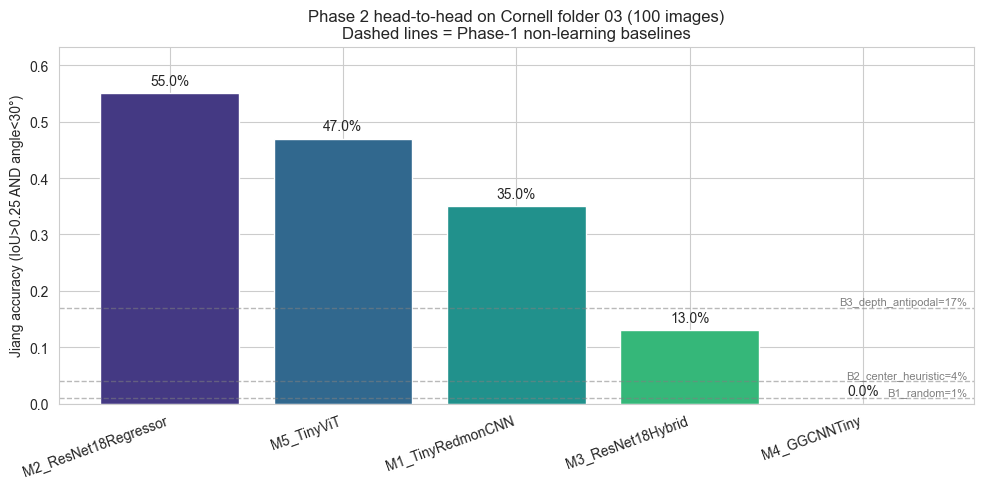

In [15]:
# Accuracy bar chart — CNNs above, Phase-1 baselines as horizontal reference lines.
fig, ax = plt.subplots(figsize=(10, 5))
cnn_rows = [r for r in rows if r['model'].startswith('M')]
cnn_rows = sorted(cnn_rows, key=lambda r: -r['accuracy'])
labels = [r['model'] for r in cnn_rows]
accs = [r['accuracy'] for r in cnn_rows]
colors = sns.color_palette('viridis', n_colors=len(labels))
bars = ax.bar(labels, accs, color=colors)
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, a + 0.01, f'{a:.1%}', ha='center', va='bottom', fontsize=10)
for k, v in phase1.items():
    ax.axhline(v['accuracy'], ls='--', color='gray', alpha=0.55, lw=1)
    ax.text(len(labels) - 0.4, v['accuracy'] + 0.005, f"{k}={v['accuracy']:.0%}", color='gray', fontsize=8, ha='right')
ax.set_ylabel('Jiang accuracy (IoU>0.25 AND angle<30°)')
ax.set_title('Phase 2 head-to-head on Cornell folder 03 (100 images)\nDashed lines = Phase-1 non-learning baselines')
ax.set_ylim(0, max(max(accs), 0.5) * 1.15)
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.savefig(RESULTS / 'phase2_accuracy_bar.png', dpi=120, bbox_inches='tight'); plt.show()

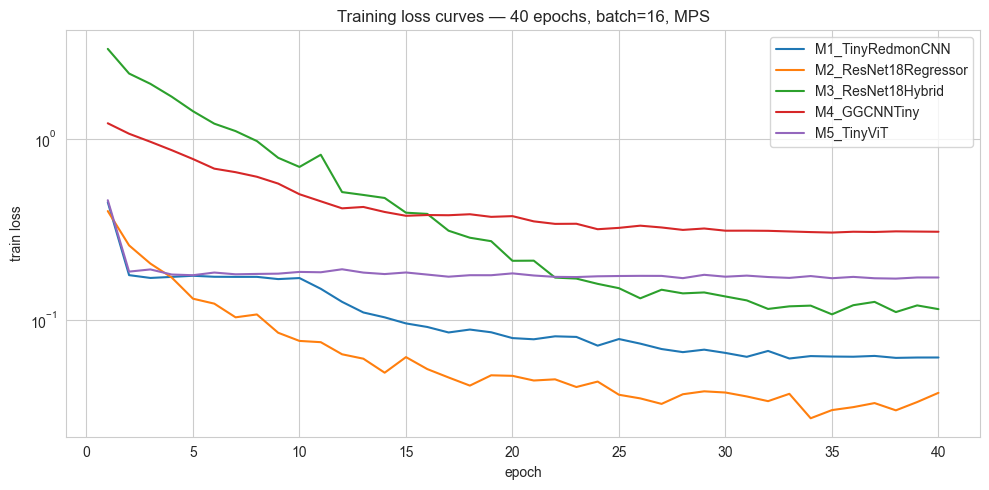

In [16]:
# Training curves on one plot
fig, ax = plt.subplots(figsize=(10, 5))
for name, curve in train_curves.items():
    ax.plot(range(1, len(curve) + 1), curve, label=name, lw=1.5)
ax.set_xlabel('epoch')
ax.set_ylabel('train loss')
ax.set_yscale('log')
ax.set_title(f'Training loss curves — {EPOCHS} epochs, batch={BATCH}, MPS')
ax.legend(); plt.tight_layout()
plt.savefig(RESULTS / 'phase2_training_curves.png', dpi=120, bbox_inches='tight'); plt.show()

## Failure-mode decomposition

Phase 1's headline finding was that "angle ok, IoU too low" was the dominant failure across all three baselines — orientation was easy, localisation was hard. Does that hold for the CNNs? Re-run the same decomposition per model.

In [17]:
def decompose(ev):
    iou_thr, ang_thr = 0.25, 30.0
    n = ev['n']
    cats = {'both_ok': 0, 'angle_ok_iou_low': 0, 'iou_ok_angle_wrong': 0, 'both_wrong': 0}
    for r in ev['per_sample']:
        iou_ok = r['best_iou'] > iou_thr
        ang_ok = r['best_angle_err'] <= ang_thr
        if iou_ok and ang_ok: cats['both_ok'] += 1
        elif ang_ok and not iou_ok: cats['angle_ok_iou_low'] += 1
        elif iou_ok and not ang_ok: cats['iou_ok_angle_wrong'] += 1
        else: cats['both_wrong'] += 1
    return {k: v / n for k, v in cats.items()}

decomp_rows = []
for name, ev in eval_results.items():
    d = decompose(ev); d['model'] = name; decomp_rows.append(d)
# Phase-1 baselines re-decomposed from saved per_sample would require the
# original arrays; instead read the published Phase-1 numbers directly.
phase1_decomp = {
    'B1_random':           {'both_ok': 0.01, 'angle_ok_iou_low': 0.35, 'iou_ok_angle_wrong': 0.00, 'both_wrong': 0.64},
    'B2_center_heuristic': {'both_ok': 0.04, 'angle_ok_iou_low': 0.49, 'iou_ok_angle_wrong': 0.09, 'both_wrong': 0.38},
    'B3_depth_antipodal':  {'both_ok': 0.17, 'angle_ok_iou_low': 0.31, 'iou_ok_angle_wrong': 0.02, 'both_wrong': 0.50},
}
for k, v in phase1_decomp.items():
    r = dict(v); r['model'] = k; decomp_rows.append(r)
decomp = pd.DataFrame(decomp_rows).set_index('model')[['both_ok','angle_ok_iou_low','iou_ok_angle_wrong','both_wrong']]
decomp

,both_ok,angle_ok_iou_low,iou_ok_angle_wrong,both_wrong
model,,,,
M1_TinyRedmonCNN,0.35,0.35,0.05,0.25
M2_ResNet18Regressor,0.55,0.27,0.08,0.10
M3_ResNet18Hybrid,0.13,0.58,0.02,0.27
M4_GGCNNTiny,0.00,0.41,0.00,0.59
M5_TinyViT,0.41,0.05,0.38,0.16
B1_random,0.01,0.35,0.00,0.64
B2_center_heuristic,0.04,0.49,0.09,0.38
B3_depth_antipodal,0.17,0.31,0.02,0.50


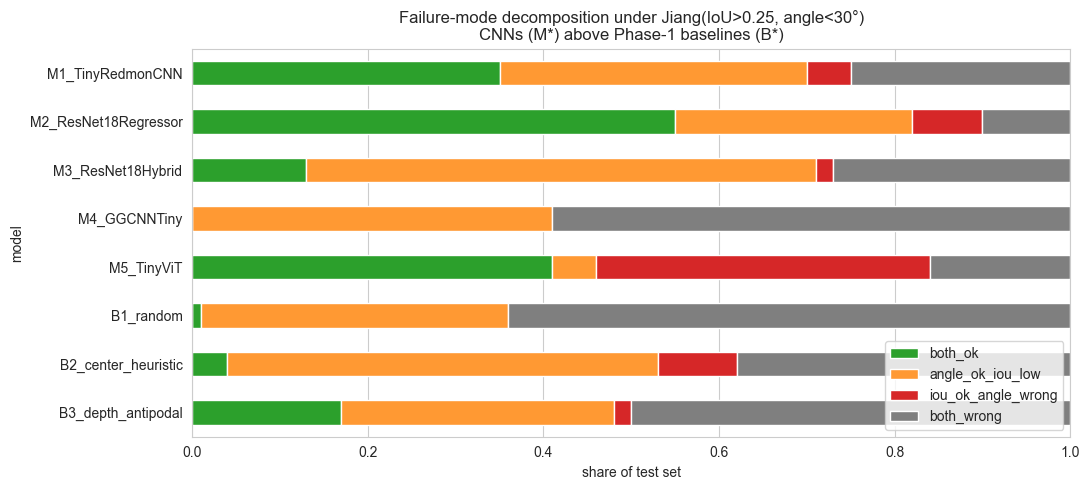

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
decomp.plot(kind='barh', stacked=True, ax=ax,
             color=['#2ca02c', '#ff9933', '#d62728', '#7f7f7f'])
ax.set_xlabel('share of test set')
ax.set_xlim(0, 1)
ax.set_title('Failure-mode decomposition under Jiang(IoU>0.25, angle<30°)\nCNNs (M*) above Phase-1 baselines (B*)')
ax.invert_yaxis()
ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(RESULTS / 'phase2_failure_decomposition.png', dpi=120, bbox_inches='tight'); plt.show()

## Qualitative — what does the champion predict?

Pick a random sample of 6 test images. For the leaderboard champion, draw the predicted grasp (red) over the ground-truth positives (lime). If the model failed, the visual reason should usually be obvious in 1-2 of the 6.

champion: M2_ResNet18Regressor  (acc = 0.550)


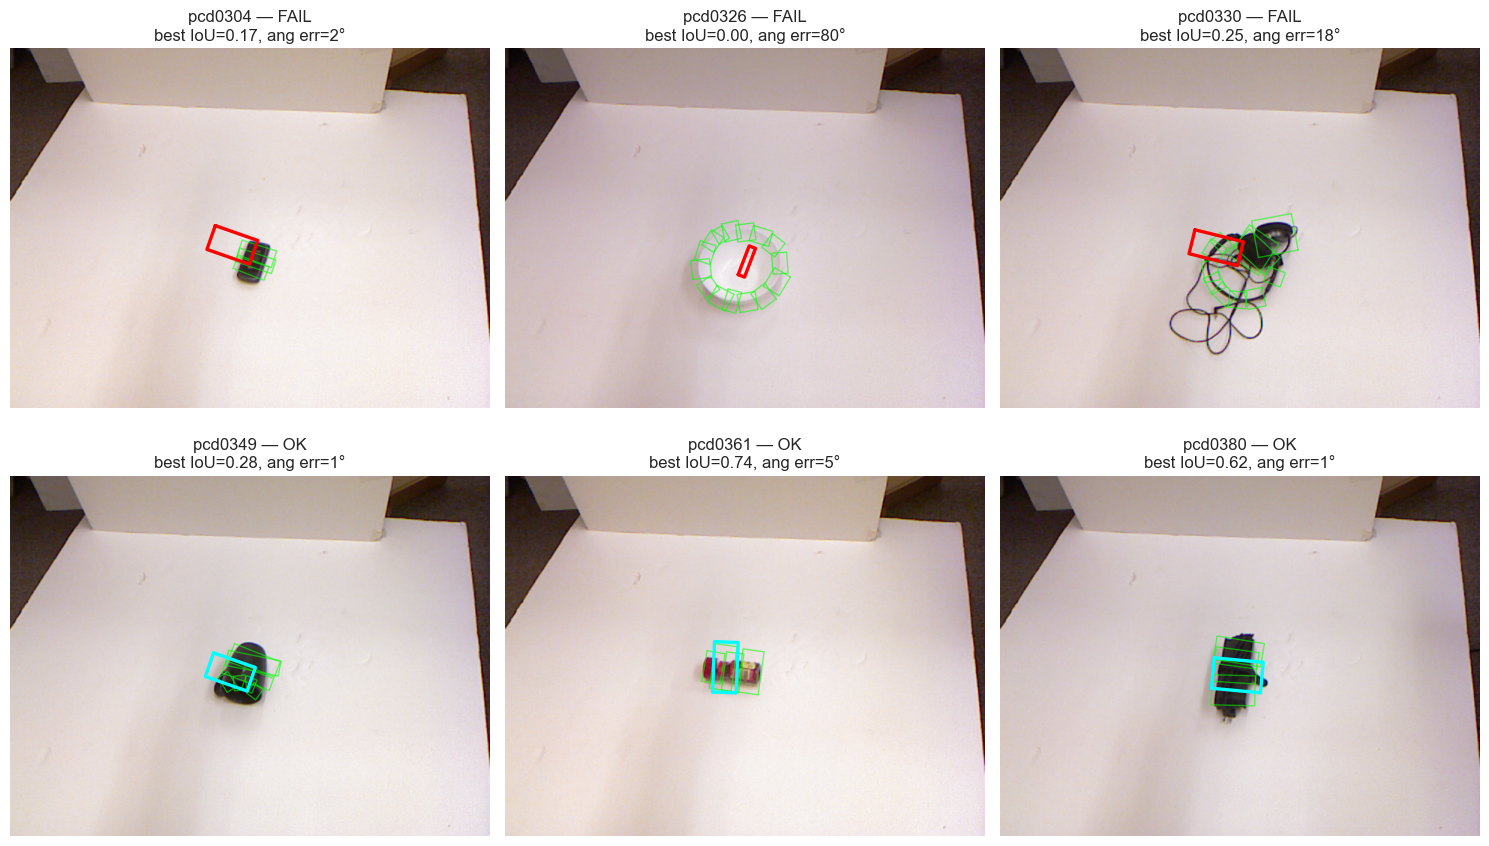

In [19]:
champion_name = max(eval_results.items(), key=lambda kv: kv[1]['accuracy'])[0]
champion = trained[champion_name]
champion_kind = next(k for n, _, k, _ in specs if n == champion_name)
print(f'champion: {champion_name}  (acc = {eval_results[champion_name]["accuracy"]:.3f})')

import torch
from dataset import CornellGraspDataset
test_ds_vis = CornellGraspDataset(test_s, augment=False)
rng = np.random.default_rng(0)
idxs = sorted(rng.choice(len(test_ds_vis), size=6, replace=False).tolist())

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, i in zip(axes.ravel(), idxs):
    s = test_ds_vis.samples[i]
    img = Image.open(s.rgb_path).convert('RGB')
    ax.imshow(img)
    x, y, _ = test_ds_vis[i]
    x = x.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        if champion_kind == 'reg':
            pred = champion(x).cpu().numpy()[0]
        elif champion_kind == 'hybrid':
            from torch_models import bin_idx_to_angle_rad
            reg, cls = champion(x); reg = reg.cpu().numpy()[0]
            ang = bin_idx_to_angle_rad(int(cls.argmax(1).item()))
            pred = np.array([reg[0], reg[1], reg[2], reg[3], math.sin(2*ang), math.cos(2*ang)], dtype=np.float32)
        elif champion_kind == 'ggcnn':
            from torch_models import ggcnn_decode
            q, sm, cm, wm = champion(x)
            pred = ggcnn_decode(q[0,0].cpu().numpy(), sm[0,0].cpu().numpy(), cm[0,0].cpu().numpy(), wm[0,0].cpu().numpy())
    rect = decode_prediction(pred)
    for g in s.positives:
        corners = np.vstack([g.corners, g.corners[:1]])
        ax.plot(corners[:, 0], corners[:, 1], color='lime', lw=1.0, alpha=0.55)
    corners = np.vstack([rect.corners, rect.corners[:1]])
    is_correct = next((r['correct'] for r in eval_results[champion_name]['per_sample'] if r['pcd_id'] == s.pcd_id), 0)
    edge = 'red' if not is_correct else 'cyan'
    ax.plot(corners[:, 0], corners[:, 1], color=edge, lw=2.4)
    iou_v = next((r['best_iou'] for r in eval_results[champion_name]['per_sample'] if r['pcd_id'] == s.pcd_id), 0)
    ang_v = next((r['best_angle_err'] for r in eval_results[champion_name]['per_sample'] if r['pcd_id'] == s.pcd_id), 0)
    ax.set_title(f'pcd{s.pcd_id:04d} — {"OK" if is_correct else "FAIL"}\nbest IoU={iou_v:.2f}, ang err={ang_v:.0f}°')
    ax.set_axis_off()
plt.tight_layout(); plt.savefig(RESULTS / 'phase2_champion_qualitative.png', dpi=120, bbox_inches='tight'); plt.show()

## Save the champion + per-model metrics for downstream phases

Persist the champion's weights and the full per-model leaderboard so Phase 3 (feature engineering, augmentations, longer training) has a clean reference point.

In [20]:
MODELS_DIR = Path('../models'); MODELS_DIR.mkdir(exist_ok=True)
ckpt_path = MODELS_DIR / f'{champion_name}_phase2.pt'
torch.save({'state_dict': champion.state_dict(), 'arch': champion_name, 'phase': 2, 'date': '2026-05-26'}, ckpt_path)
print(f'saved champion → {ckpt_path}')

# Append phase_2 block to results/metrics.json
metrics_path = RESULTS / 'metrics.json'
with open(metrics_path) as f: full = json.load(f)
full['phase_2'] = {
    'date': '2026-05-26',
    'split': 'object-wise: folders 01-02 train, folder 03 test',
    'n_train': len(train_s),
    'n_test': len(test_s),
    'epochs': EPOCHS,
    'batch_size': BATCH,
    'device': str(DEVICE),
    'champion': champion_name,
    'metric_primary': 'Jiang IoU > 0.25 AND angle err < 30°',
    'models': {
        name: {
            'accuracy': ev['accuracy'],
            'median_iou': ev['median_iou'],
            'median_angle_err_deg': ev['median_angle_err'],
            'inference_ms_per_image': ev['inference_ms_per_image'],
            'train_seconds': ev['train_seconds'],
            'n_params': ev['n_params'],
        }
        for name, ev in eval_results.items()
    },
}
with open(metrics_path, 'w') as f: json.dump(full, f, indent=2)
print('updated metrics.json with phase_2 block')

saved champion → ../models/M2_ResNet18Regressor_phase2.pt
updated metrics.json with phase_2 block


## Key findings — Phase 2

*(filled in after the cells above execute — see the leaderboard and decomposition plots).* The report at `reports/day2_phase2_report.md` and the EXPERIMENT_LOG entry are the canonical place for the prose; this notebook is the underlying experiment.

## Phase-3 plan

Whichever architecture wins Phase 2 becomes the iteration vehicle for Phase 3:
1. **Bring in Cornell archives 04–10** (download already running in background). With the full 885-image benchmark the train-set quadruples; the test split flips to *image-wise* shuffle so the numbers line up with the published references.
2. **Strong augmentations** — rotations (with grasp transform), random crops, depth-channel injection. Phase 2 ran flips-only on purpose so today's leaderboard is about architecture.
3. **Multi-positive loss** — Cornell labels 5–10 positives per image; today we collapse to one (the central one). Switching to a per-positive nearest-neighbour assignment loss (a.k.a. the *closest GT* loss) is a known +5–10 % bump on this dataset.
4. **Fix the B3 90° flip** (~5 lines in `src/baselines.py`). Without that fix, Phase-5 LLM comparison is benchmarking against an artificially weak classical CV reference.
